L = 5, N = 2, dim = 15
U = 260.820 Hz (static)
V0 ramp:    20.000 -> 7.500 Er, -20.0 -> 0.0 ms (cosine)
  -> J:     3.085 -> 43.323 Hz
Delta ramp: 0.000 -> 0.000 Hz, -20.0 -> 0.0 ms (linear)
initial state = (0, 1, 0, 1, 0)
final norm = 0.9999999785517291


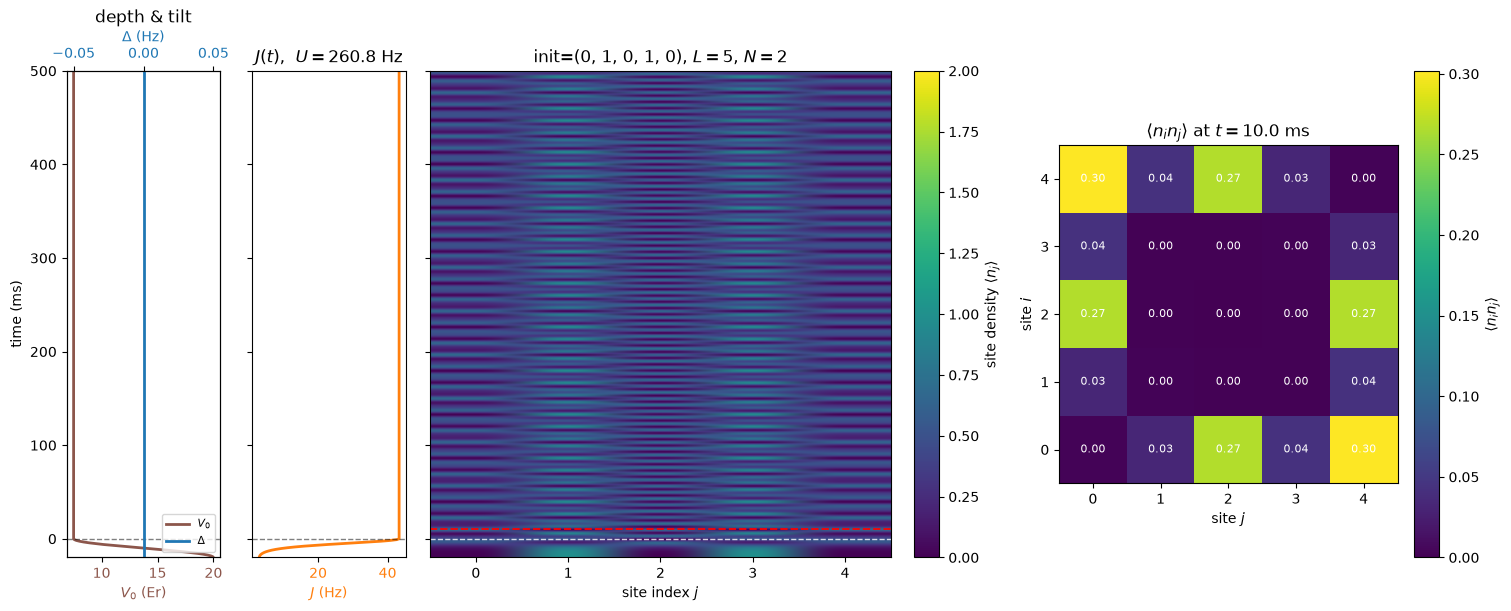

In [75]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =============================================================
# evolve_grad_V0_ramp
#   Non-Floquet (no lattice modulation) evolution of an initial
#   Fock state under independent ramps of the lattice depth V0(t)
#   and the linear tilt/gradient Delta(t). The tunneling follows
#   the lattice depth through its empirical conversion map,
#       J(t) = V_to_J(V0(t)),
#   while the on-site interaction U is a static parameter.
#   Because there is no depth modulation, V(t) = V0(t) (the slow
#   ramp), so J(t) simply tracks the ramp.
#
#   Plots:
#     - V0(t), J(t), and Delta(t) ramp profiles
#     - site-density heatmap vs time
#     - particle-particle correlation matrix <n_i n_j> at a chosen
#       time, with that time marked on the heatmap.
#
# Fixed internally: TIME_EVOLVE = 500 ms, PLOT_SITES = [].
# =============================================================

def evolve_grad_V0_ramp(state_init,
                        U_hz,
                        V0_range_ER,
                        t_ramp_V0,
                        RAMP_SHAPE_V0,
                        Delta_range_hz,
                        t_ramp_Delta,
                        RAMP_SHAPE_DELTA,
                        t_correlation_plot_ms):
    """
    Parameters
    ----------
    state_init : list/array of int
        Initial Fock state. Sets L = len(state_init) and N = sum(state_init).
        e.g. [0,1,0] -> N=1, L=3 ;  [0,1,0,1] -> N=2, L=4.
    U_hz : float
        Static on-site interaction (Hz).
    V0_range_ER : [V0_init_ER, V0_final_ER]
        Lattice depth (Er) at the start and end of the depth ramp.
    t_ramp_V0 : [t_V0_ramp_init_ms, t_V0_ramp_final_ms]
        Start and end times (ms) of the lattice-depth ramp.
    RAMP_SHAPE_V0 : "linear" | "cosine" | "exponential"
        Shape of the lattice-depth ramp.
    Delta_range_hz : [Delta_init_hz, Delta_final_hz]
        Gradient magnitude (Hz) at the start and end of its ramp.
    t_ramp_Delta : [t_Delta_ramp_init_ms, t_Delta_ramp_final_ms]
        Start and end times (ms) of the Delta ramp.
    RAMP_SHAPE_DELTA : "linear" | "cosine" | "exponential"
        Shape of the Delta ramp.
    t_correlation_plot_ms : float
        Time (ms) at which to evaluate and plot <n_i n_j>.
    """

    # ---- fixed parameters ----
    TIME_EVOLVE = 500.0   # hold-evolution time after t = 0 (ms)
    PLOT_SITES  = []      # site-occupation line cuts off

    # ---- unpack / normalize inputs ----
    state_init = list(state_init)
    L = len(state_init)
    N = sum(state_init)

    V0_init_ER, V0_final_ER       = V0_range_ER
    Delta_init_hz, Delta_final_hz = Delta_range_hz
    t_V0_ramp_init_ms,  t_V0_ramp_final_ms      = t_ramp_V0
    t_Delta_ramp_init_ms, t_Delta_ramp_final_ms = t_ramp_Delta

    twopi = 2.0 * np.pi

    # ---- empirical lattice-depth -> tunneling map (Er in, Hz out) ----
    def V_to_J(V):
        V = np.asarray(V, dtype=float)
        a = 284.4; b = -0.2922; c = 30.69; d = -0.1304
        return a * np.exp(b * V) + c * np.exp(d * V)

    # angular-frequency endpoints (rad/s)
    Delta_init  = twopi * Delta_init_hz
    Delta_final = twopi * Delta_final_hz
    U = twopi * U_hz                              # static interaction (rad/s)

    # ms -> s
    t_V0_init_s  = t_V0_ramp_init_ms  * 1e-3
    t_V0_final_s = t_V0_ramp_final_ms * 1e-3
    t_D_init_s   = t_Delta_ramp_init_ms  * 1e-3
    t_D_final_s  = t_Delta_ramp_final_ms * 1e-3
    TIME_EVOLVE_s = TIME_EVOLVE * 1e-3

    # ---- generic ramp helper ----
    def ramp(t, v_init, v_final, t_init, t_final, shape):
        if t_final <= t_init:               # degenerate / instantaneous
            return v_final if t >= t_final else v_init
        if t <= t_init:
            return v_init
        if t >= t_final:
            return v_final
        s = (t - t_init) / (t_final - t_init)
        if shape == "linear":
            w = s
        elif shape == "cosine":
            w = 0.5 * (1.0 - np.cos(np.pi * s))
        elif shape == "exponential":
            tau = 1.0 / 3.0
            w = (1.0 - np.exp(-s / tau)) / (1.0 - np.exp(-1.0 / tau))
        else:
            raise ValueError("shape must be 'linear', 'cosine', or 'exponential'")
        return v_init + (v_final - v_init) * w

    # ---- time-dependent controls ----
    def V0_of_t(t):
        """Instantaneous lattice depth (Er)."""
        return ramp(t, V0_init_ER, V0_final_ER, t_V0_init_s, t_V0_final_s, RAMP_SHAPE_V0)

    def J_angular_of_t(t):
        """Instantaneous tunneling (rad/s) from the depth->J map."""
        return twopi * V_to_J(V0_of_t(t))

    def Delta_of_t(t):
        """Instantaneous tilt (rad/s)."""
        return ramp(t, Delta_init, Delta_final, t_D_init_s, t_D_final_s, RAMP_SHAPE_DELTA)

    # ---- fixed-N basis ----
    def generate_basis(L, N):
        return [tuple(occ) for occ in itertools.product(range(N + 1), repeat=L)
                if sum(occ) == N]
    basis = generate_basis(L, N)
    index = {s: i for i, s in enumerate(basis)}
    dim   = len(basis)

    print("L = %d, N = %d, dim = %d" % (L, N, dim))
    print("U = %.3f Hz (static)" % U_hz)
    print("V0 ramp:    %.3f -> %.3f Er, %.1f -> %.1f ms (%s)"
          % (V0_init_ER, V0_final_ER, t_V0_ramp_init_ms, t_V0_ramp_final_ms,
             RAMP_SHAPE_V0))
    print("  -> J:     %.3f -> %.3f Hz" % (V_to_J(V0_init_ER), V_to_J(V0_final_ER)))
    print("Delta ramp: %.3f -> %.3f Hz, %.1f -> %.1f ms (%s)"
          % (Delta_init_hz, Delta_final_hz, t_Delta_ramp_init_ms,
             t_Delta_ramp_final_ms, RAMP_SHAPE_DELTA))

    # ---- Hamiltonian pieces (unit prefactors; couplings applied in rhs) ----
    def build_hop_unit():
        H = np.zeros((dim, dim), dtype=complex)
        for a, state in enumerate(basis):
            n = np.array(state)
            for j in range(L-1):
                if n[j] > 0:
                    new = n.copy(); amp = np.sqrt(n[j])*np.sqrt(n[j+1]+1)
                    new[j]-=1; new[j+1]+=1
                    H[index[tuple(new)], a] += -amp
                if n[j+1] > 0:
                    new = n.copy(); amp = np.sqrt(n[j+1])*np.sqrt(n[j]+1)
                    new[j+1]-=1; new[j]+=1
                    H[index[tuple(new)], a] += -amp
        return H

    def build_tilt_unit():
        H = np.zeros((dim, dim), dtype=complex)
        sites = np.arange(L)
        for a, state in enumerate(basis):
            n = np.array(state)
            H[a, a] = -np.sum(sites * n)
        return H

    def build_int():
        """Static on-site interaction (U/2) sum_j n_j(n_j-1)."""
        H = np.zeros((dim, dim), dtype=complex)
        for a, state in enumerate(basis):
            n = np.array(state)
            H[a, a] = 0.5 * U * np.sum(n * (n - 1))
        return H

    H_hop_unit  = build_hop_unit()
    H_tilt_unit = build_tilt_unit()
    H_int       = build_int()

    # ---- site-density operators ----
    n_ops = []
    for site in range(L):
        op = np.zeros((dim, dim), dtype=complex)
        for a, state in enumerate(basis):
            op[a, a] = state[site]
        n_ops.append(op)

    # ---- initial state vector ----
    psi0 = np.zeros(dim, dtype=complex)
    psi0[index[tuple(state_init)]] = 1.0
    print("initial state =", tuple(state_init))

    # ---- time evolution (J time-dependent, U static) ----
    def rhs(t, psi):
        H = (J_angular_of_t(t) * H_hop_unit
             + Delta_of_t(t)   * H_tilt_unit
             + H_int)
        return -1j * H.dot(psi)

    t_start = min(0.0, t_V0_init_s, t_D_init_s)
    t_end   = TIME_EVOLVE_s
    n_times = 600
    times = np.linspace(t_start, t_end, n_times)

    ramp_durations = [d for d in (t_V0_final_s - t_V0_init_s,
                                  t_D_final_s - t_D_init_s) if d > 0]
    max_step = (min(ramp_durations) / 50.0) if ramp_durations else np.inf

    sol = solve_ivp(rhs, (t_start, t_end), psi0, t_eval=times,
                    rtol=1e-10, atol=1e-10, method="RK45", max_step=max_step)
    psis = sol.y.T
    print("final norm =", np.linalg.norm(psis[-1]))

    # ---- density vs time ----
    density = np.zeros((len(times), L))
    for ti, p in enumerate(psis):
        for site in range(L):
            density[ti, site] = np.vdot(p, n_ops[site].dot(p)).real

    # ---- correlation matrix at t_correlation_plot_ms ----
    n_basis = np.array([list(s) for s in basis], dtype=float)

    def state_at_time(t_query_s):
        if t_query_s <= times[0]:
            return psis[0]
        if t_query_s >= times[-1]:
            return psis[-1]
        k = np.searchsorted(times, t_query_s) - 1
        k = min(max(k, 0), len(times) - 2)
        frac = (t_query_s - times[k]) / (times[k+1] - times[k])
        psi = (1.0 - frac) * psis[k] + frac * psis[k+1]
        nrm = np.linalg.norm(psi)
        return psi / nrm if nrm > 0 else psi

    t_corr_s = t_correlation_plot_ms * 1e-3
    psi_corr = state_at_time(t_corr_s)
    prob_corr = np.abs(psi_corr)**2

    # G_ij = <n_i n_j> with the i==j diagonal carrying <n_i(n_i-1)>
    G_corr = np.zeros((L, L), dtype=float)
    for k in range(dim):
        n = n_basis[k]
        for i in range(L):
            for j in range(L):
                if i == j:
                    G_corr[i, j] += prob_corr[k] * n[i] * (n[i] - 1)
                else:
                    G_corr[i, j] += prob_corr[k] * n[i] * n[j]

    # ---- ramp profiles for the side panel ----
    times_ms      = 1000.0 * times
    V0_profile_ER = np.array([V0_of_t(t) for t in times])
    J_profile_hz  = V_to_J(V0_profile_ER)
    Delta_profile_hz = np.array([Delta_of_t(t) for t in times]) / twopi

    # ---- figure: ramp profiles | density heatmap | correlation matrix ----
    fig = plt.figure(figsize=(15, 6), constrained_layout=True)
    gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 3, 2.2], wspace=0.05)
    axL  = fig.add_subplot(gs[0, 0])               # V0 and Delta
    axJU = fig.add_subplot(gs[0, 1], sharey=axL)   # J and U
    axR  = fig.add_subplot(gs[0, 2], sharey=axL)   # density heatmap
    axC  = fig.add_subplot(gs[0, 3])               # correlation matrix

    # panel 1: V0(t) and Delta(t)
    lnV, = axL.plot(V0_profile_ER, times_ms, color="tab:brown", lw=2.0, label=r"$V_0$")
    axL.set_xlabel(r"$V_0$ (Er)", color="tab:brown")
    axL.tick_params(axis="x", labelcolor="tab:brown")
    axL.set_ylabel("time (ms)")
    axL.axhline(0.0, color="k", lw=1.0, ls="--", alpha=0.5)
    axL.set_title("depth & tilt")
    axL.margins(y=0)

    axLt = axL.twiny()
    lnD, = axLt.plot(Delta_profile_hz, times_ms, color="tab:blue", lw=2.0, label=r"$\Delta$")
    axLt.set_xlabel(r"$\Delta$ (Hz)", color="tab:blue")
    axLt.tick_params(axis="x", labelcolor="tab:blue")
    axL.legend(handles=[lnV, lnD], loc="lower right", fontsize=8)

    # panel 2: J(t)  (U is static -> reported in the title)
    lnJ, = axJU.plot(J_profile_hz, times_ms, color="tab:orange", lw=2.0, label=r"$J$")
    axJU.set_xlabel(r"$J$ (Hz)", color="tab:orange")
    axJU.tick_params(axis="x", labelcolor="tab:orange")
    axJU.axhline(0.0, color="k", lw=1.0, ls="--", alpha=0.5)
    axJU.set_title(r"$J(t)$,  $U=%.1f$ Hz" % U_hz)
    axJU.tick_params(labelleft=False)

    # panel 3: density heatmap
    im = axR.imshow(density, aspect="auto", origin="lower",
                    extent=[-0.5, L-0.5, times_ms[0], times_ms[-1]],
                    cmap="viridis", vmin=0.0, vmax=N)
    axR.axhline(0.0, color="w", lw=1.0, ls="--", alpha=0.8)
    axR.axhline(t_correlation_plot_ms, color="r", lw=1.4, ls="--", alpha=0.9)
    axR.set_xlabel("site index $j$")
    axR.set_xticks(range(L))
    axR.set_title(r"init=%s, $L=%d$, $N=%d$" % (tuple(state_init), L, N))
    axR.tick_params(labelleft=False)
    fig.colorbar(im, ax=axR, label=r"site density $\langle n_j \rangle$")

    # panel 4: correlation matrix
    imC = axC.imshow(G_corr, origin="lower", cmap="viridis", vmin=0.0)
    axC.set_xticks(range(L)); axC.set_yticks(range(L))
    axC.set_xlabel("site $j$"); axC.set_ylabel("site $i$")
    axC.set_title(r"$\langle n_i n_j\rangle$ at $t=%.1f$ ms" % t_correlation_plot_ms)
    fig.colorbar(imC, ax=axC, label=r"$\langle n_i n_j \rangle$")
    if L <= 8:
        for i in range(L):
            for j in range(L):
                axC.text(j, i, "%.2f" % G_corr[i, j], ha="center", va="center",
                         color="w", fontsize=8)

    plt.savefig("evolve_grad_V0_ramp.png", dpi=120)
    plt.show()


# =============================================================
# Example call
# =============================================================
if __name__ == "__main__":
    evolve_grad_V0_ramp(
        state_init            = [0, 1, 0, 1, 0],
        U_hz                  = 260.82,
        V0_range_ER           = [20.0, 7.5],
        t_ramp_V0             = [-20.0, 0.0],
        RAMP_SHAPE_V0         = "cosine",
        Delta_range_hz        = [0.0, 0.0],
        t_ramp_Delta          = [-20.0, 0.0],
        RAMP_SHAPE_DELTA      = "linear",
        t_correlation_plot_ms = 10.0,
    )

L = 5, N = 2, dim = 15
U = 16.640 Hz (static)
V0 ramp:    45.000 -> 13.500 Er, -260.0 -> -250.0 ms (cosine)
  -> J:     0.087 -> 10.783 Hz
Delta ramp: 44.720 -> 0.000 Hz, -250.0 -> 0.0 ms (cosine)
initial state = (0, 0, 0, 0, 2)
final norm = 0.9999999565328184


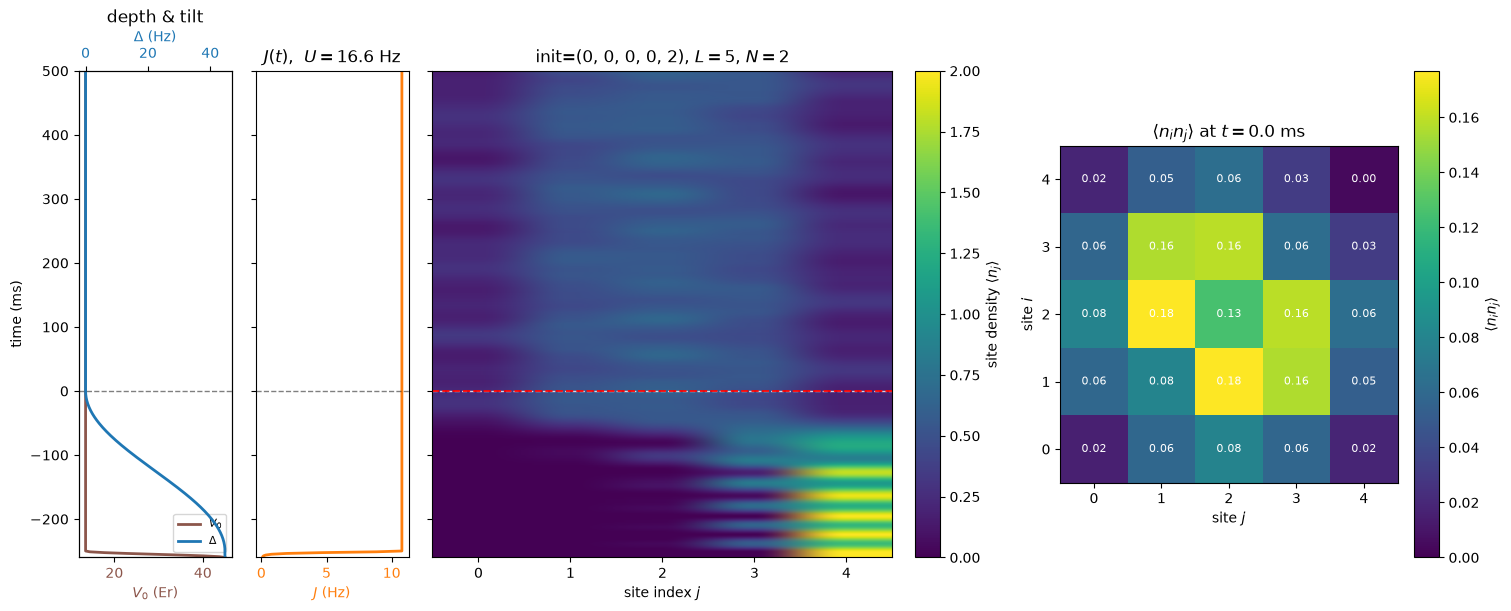

In [77]:
grad_ramp_dur = 250
lattice_ramp_dur = 10
J_hz_eff = 10.4

evolve_grad_V0_ramp(
        state_init            = [0,0,0,0,2],
        U_hz                  = 1.6 * J_hz_eff,
        V0_range_ER           = [45, 13.5],
        t_ramp_V0             = [-grad_ramp_dur-lattice_ramp_dur, -grad_ramp_dur],
        RAMP_SHAPE_V0         = "cosine",
        Delta_range_hz        = [J_hz_eff * 4.3, 0.0],
        t_ramp_Delta          = [-grad_ramp_dur, 0.0],
        RAMP_SHAPE_DELTA      = "cosine",
        t_correlation_plot_ms = 0.0,
    )